In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df= pd.read_csv("insurance.csv")

In [6]:
df= pd.DataFrame(df)

In [7]:
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [9]:
df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [10]:
df.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

In [11]:
df.shape

(1338, 7)

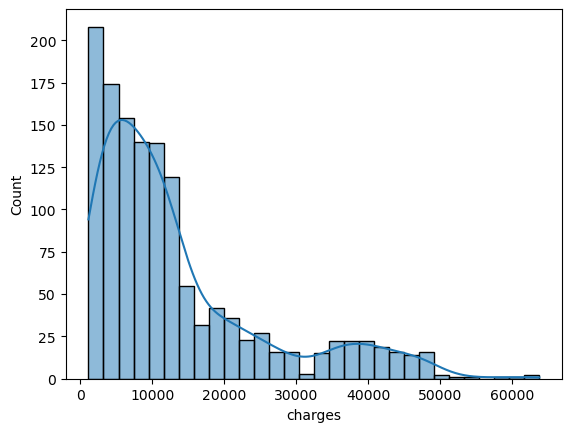

In [12]:
sns.histplot(df['charges'], kde=True)
plt.show()

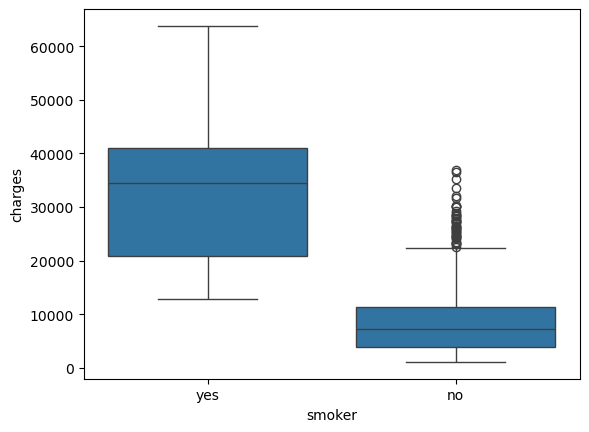

In [13]:
sns.boxplot(x='smoker', y='charges', data= df)
plt.show()

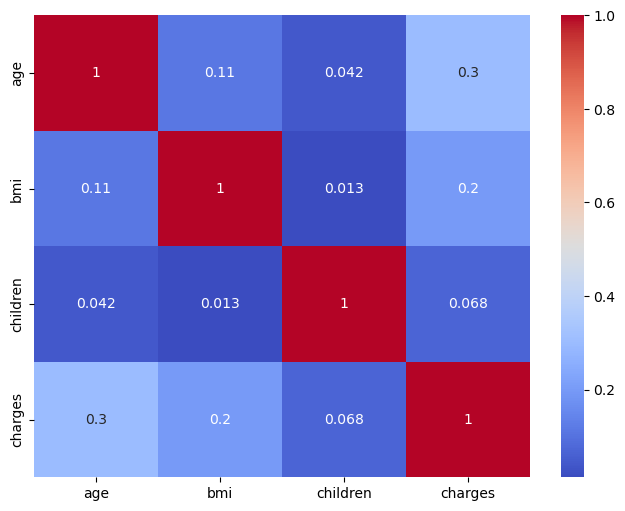

In [17]:
numerical_df= df.select_dtypes(include=['int64', 'float64'])

plt.figure(figsize=(8, 6))
sns.heatmap(numerical_df.corr(), annot=True, cmap= 'coolwarm')
plt.show()

In [18]:
x= df.drop('charges', axis=1)
y= df["charges"]

In [21]:
x.dtypes

age           int64
sex          object
bmi         float64
children      int64
smoker       object
region       object
dtype: object

In [23]:
x= pd.get_dummies(x, drop_first= True)

In [24]:
print(x.shape)

(1338, 8)


In [25]:
x.head()

,age,bmi,children,sex_male,smoker_yes,region_northwest,region_southeast,region_southwest
0,19,27.900,0,False,True,False,False,True
1,18,33.770,1,True,False,False,True,False
2,28,33.000,3,True,False,False,True,False
3,33,22.705,0,True,False,True,False,False
4,32,28.880,0,True,False,True,False,False


In [28]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test= train_test_split(
    x,
    y,
    test_size=0.2,
    random_state= 42
)

In [29]:
print(x_train.shape)
print(x_test.shape)
print(y_train.shape)
print(y_test.shape)

(1070, 8)
(268, 8)
(1070,)
(268,)


In [31]:
from sklearn.preprocessing import StandardScaler
scaler= StandardScaler()
x_train=scaler.fit_transform(x_train)
x_test= scaler.transform(x_test)

In [32]:
print(x_train.shape)
print(x_test.shape)

(1070, 8)
(268, 8)


In [33]:
from sklearn.linear_model import LinearRegression
lr= LinearRegression()

In [34]:
lr.fit( x_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [37]:
y_pred= lr.predict(x_test)

In [38]:
from sklearn.metrics import(mean_absolute_error, mean_squared_error, r2_score)

In [42]:
mae= mean_absolute_error(y_test, y_pred)
print(mae)

4181.194473753653


In [45]:
rmse= np.sqrt(mean_squared_error(y_test, y_pred))
print(rmse)

5796.284659276275


In [44]:
r2= r2_score(y_test, y_pred)
print(r2)

0.7835929767120722


In [46]:
from sklearn.linear_model import Ridge
ridge= Ridge()
ridge.fit(x_train, y_train)

,alpha,1.0
,fit_intercept,True
,copy_X,True
,max_iter,None
,tol,0.0001
,solver,'auto'
,positive,False
,random_state,None


In [47]:
ridge_pred= ridge.predict(x_test)

In [52]:
ridge_mae= mean_absolute_error(y_test, ridge_pred)
print(ridge_mae)

4182.7965965832645


In [53]:
ridge_rmse= np.sqrt(mean_squared_error(y_test, ridge_pred))
print(ridge_rmse)

5796.979691180858


In [54]:
ridge_r2= r2_score(y_test, ridge_pred)
print(ridge_r2)

0.7835410749121385


In [55]:
from sklearn.linear_model import Lasso
ls= Lasso()

In [56]:
ls.fit(x_train, y_train)

,alpha,1.0
,fit_intercept,True
,precompute,False
,copy_X,True
,max_iter,1000
,tol,0.0001
,warm_start,False
,positive,False
,random_state,None
,selection,'cyclic'


In [61]:
ls_pred= ls.predict(x_test)

In [63]:
ls_mae= mean_absolute_error(y_test, ls_pred)
print(ls_mae)

4181.510231838869


In [66]:
ls_rmse= np.sqrt(mean_squared_error(y_test, ls_pred))
print(ls_rmse)

5796.649550964598


In [68]:
ls_r2= r2_score(y_test, ls_pred)
print(ls_r2)

0.7835657290476568


In [69]:
from sklearn.ensemble import RandomForestRegressor

In [74]:
rf= RandomForestRegressor(random_state=42)
rf.fit(x_train, y_train)

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [75]:
rf_pred= rf.predict(x_test)

In [76]:
rf_mae= mean_absolute_error(y_test, rf_pred)
print(rf_mae)

2543.9758251029275


In [77]:
rf_rmse= np.sqrt(mean_squared_error(y_test, rf_pred))
print(rf_rmse)

4567.775116331386


In [85]:
rf_r2= r2_score(y_test, rf_pred)
print(rf_r2)

0.8656055394920775


In [86]:
results= pd.DataFrame({
    'Model': [
    'LinearRegression',
    'Ridge',
    'Lasso',
    'RandomForestRegressor'
    ],
    'MAE':[
        mae,
        ridge_mae,
        ls_mae,
        rf_mae
    ],
    'RMSE':[
        rmse,
        ridge_rmse,
        ls_rmse,
        rf_rmse
    ],
    'r2_score':[
        r2,
        ridge_r2,
        ls_r2,
        rf_r2
    ]
})
results

,Model,MAE,RMSE,r2_score
0,LinearRegression,4181.194474,5796.284659,0.783593
1,Ridge,4182.796597,5796.979691,0.783541
2,Lasso,4181.510232,5796.649551,0.783566
3,RandomForestRegressor,2543.975825,4567.775116,0.865606


In [88]:
feature_importance = pd.DataFrame({
    'Feature': x.columns,
    'Importance': rf.feature_importances_
})

feature_importance.sort_values(
    by='Importance',
    ascending=False
)

,Feature,Importance
4,smoker_yes,0.608618
1,bmi,0.216506
0,age,0.134232
2,children,0.019413
3,sex_male,0.006379
5,region_northwest,0.005587
6,region_southeast,0.005314
7,region_southwest,0.003950
